# Particle Filters for Geosteering
As a DS, it's my first time hearing about particle filters and this problematic is a first of a kind for me. While understanding of data got clearer to me. the common techniques of autonomous navigation were new to me and i couldn't understand them from pure code and maths. and i think visuals are the best way to understand these techniques. the following notebook helped me a lot visualize the math behind particle filters on this particular problem. **Hope you find it Helpful too, GOOD READING!**

Feel free to use it to generate GIFS and share them in discussions.

## 1. The experiment / problem setup

In horizontal drilling (*geosteering*) the bit travels nearly sideways through a thin
target rock layer. We know the well's **geometry** precisely (its measured depth `MD`
and true-vertical `Z` at every point), but we do **not** know how the rock layers
undulate beneath us — i.e. the **TVT** (*true vertical thickness*: the structural
position of the geology relative to a reference).

What we *do* have:

- a nearby vertical **typewell** that logged gamma-ray (`GR`) versus depth — a 1-D
  "map" of what the rock *should* look like at each TVT;
- the **early, known** part of the horizontal well, where TVT is given (`TVT_input`);
- the horizontal well's own **gamma-ray** reading all along the lateral.

**Goal:** from the moment `TVT_input` runs out, predict TVT for the rest of the lateral.
We score it with RMSE against the held-out truth. This notebook is about *understanding*
the estimator, so we run on a **train** well where the true TVT is available to overlay.

## 2. What we'll use

| Ingredient | Role |
|---|---|
| Horizontal-well `GR` | the live **sensor** stream of Gamma rays|
| Horizontal-well `Z` (and `MD`) | **known** wellbore geometry |
| Typewell `GR(TVT)` curve | the GR of the guessed TVT|
| Known `TVT_input` lead-in | where we **start** and how we calibrate noise |
| A **particle filter** | the estimator that fuses motion + sensor over time |

## 3. Particle filters as autonomous navigation

A robot doing **Monte-Carlo Localization** doesn't know exactly where it is. So it keeps
hundreds of guesses — *particles* — each a hypothesis "maybe I'm *here*". Every tick it:

1. **moves** every particle by the commanded motion (+ a little noise),
2. **senses** the world and up-weights particles whose predicted reading matches reality,
3. **resamples** — keeps the good hypotheses, drops the bad ones,

…and the cloud of particles collapses onto the true pose. Our geosteering problem is the
**same algorithm**, term for term:

| Robot localization | Geosteering (this notebook) |
|---|---|
| Robot pose on a map | Geological position **TVT** |
| Wheel odometry / motion command | Smooth structural **dip** (momentum motion model) |
| Laser/sonar range sensor | **Gamma-ray** log |
| Known map of the environment | **Typewell** `GR(TVT)` curve |
| Particle = pose hypothesis | Particle = TVT hypothesis |
| Sensor likelihood | How well observed `GR` ≈ typewell `GR(TVT)` |

So watching the filter work *is* watching a robot localize itself — just in a 1-D
geological coordinate instead of a 2-D floor plan.

### The one modelling trick: track `pos = TVT + Z`

The wellbore's vertical wiggle `Z` is **known exactly**, while the geology (`TVT`) is the
smooth thing we want. If we tracked TVT directly, the particles would have to reproduce
every known wellbore jiggle. Instead each particle carries a **structural position**

$$\text{pos} = \text{TVT} + Z,$$

evolves it with a gentle momentum model, and recovers $\text{TVT} = \text{pos} - Z$ using
the known `Z` at each point. This decouples the *known* geometry from the *unknown*
geology, so the motion model only has to be smooth. The sensor step then compares the
observed `GR` to the typewell's `GR` at that particle's TVT.

**Update at each lateral step *i*:**

1. *Motion:* `rate ← 0.998·rate + noise`;  `pos ← pos + rate·ΔMD + noise`
2. *Sense:*  `TVT = pos − Z`;  expected `GR = typewell(TVT)`;
   weight `w ∝ exp(−½·((GR_obs − GR_exp)/σ)²)`
3. *Resample* when the effective particle count drops too low.
4. *Estimate:* `TVT̂ = Σ wⱼ·(posⱼ − Z)`

In [1]:
import os, glob, warnings, subprocess
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.animation import FuncAnimation
from IPython.display import Video, HTML, Image

warnings.filterwarnings("ignore")

In [2]:
def find_data():
    for c in ["/kaggle/input/rogii-wellbore-geology-prediction",
              "/kaggle/input/competitions/rogii-wellbore-geology-prediction"]:
        if os.path.exists(os.path.join(c, "train")):
            return c
    for p in glob.glob("/kaggle/input/**/train", recursive=True):
        return os.path.dirname(p)
    return "."                                       
DATA   = find_data()
TRAIND = os.path.join(DATA, "train")

def ids(folder):
    return sorted({os.path.basename(p).split("__")[0]
                   for p in glob.glob(os.path.join(folder, "*__horizontal_well.csv"))})

print("DATA =", DATA, "| train wells:", len(ids(TRAIND)))

DATA = /kaggle/input/competitions/rogii-wellbore-geology-prediction | train wells: 773


In [3]:
# data prep: typewell GR(TVT) curve + split into known / to-predict regions
def _prep(hw, tw):
    tw_s = tw.sort_values("TVT")
    tw_tvt = tw_s["TVT"].to_numpy(np.float64)
    tw_gr  = tw_s["GR"].fillna(tw_s["GR"].mean()).to_numpy(np.float64)
    kn = hw[hw["TVT_input"].notna()]   # TVT is known here
    ev = hw[hw["TVT_input"].isna()]    # the stretch we must predict
    return tw_tvt, tw_gr, kn, ev


def pf_trace(hw, tw, n_particles=500, seed=0):
    """
    Particle filter for TVT, instrumented to RECORD the particle cloud at every
    step so we can animate it. State per particle: pos = TVT + Z (structural
    position) and a momentum dip 'rate'. Weights come from matching the observed
    gamma-ray to the typewell's GR at each particle's hypothesised TVT.
    """
    tw_tvt, tw_gr, kn, ev = _prep(hw, tw)
    last = kn.iloc[-1]
    last_tvt = float(last["TVT_input"]); last_Z = float(last["Z"]); last_MD = float(last["MD"])

    # sigma: how noisy is GR vs the typewell at the *known* points (likelihood width)
    tw_at_k = np.interp(kn["TVT_input"].values, tw_tvt, tw_gr)
    gs = float(np.clip(np.nanstd(kn["GR"].fillna(0).values - tw_at_k), 10.0, 60.0))
    # ir: initial dip rate from the last 30 known points
    tail = kn.tail(30)
    dt = np.diff(tail["TVT_input"].values); dz = np.diff(tail["Z"].values); dm = np.diff(tail["MD"].values)
    m = dm > 0
    ir = float(np.median((dt + dz)[m] / dm[m])) if m.sum() >= 3 else 0.0

    md_v = ev["MD"].to_numpy(np.float64)
    z_v  = ev["Z"].to_numpy(np.float64)
    gr_v = hw["GR"].interpolate(limit_direction="both").fillna(tw_gr.mean()).to_numpy(np.float64)[ev.index]

    rng = np.random.default_rng(seed)
    N = n_particles
    # initial cloud around last known
    pos  = (last_tvt + last_Z) + 4.5 * rng.standard_normal(N)   
    rate = ir + 0.01 * rng.standard_normal(N)
    w = np.full(N, 1.0 / N)
    MOM, VN, PN, RP, RR, RESAMP = 0.998, 0.002, 0.005, 0.1, 0.001, 0.5
    tvt_lo, tvt_hi = tw_tvt[0] - 100.0, tw_tvt[-1] + 100.0

    n = len(md_v)
    cloud_tvt = np.empty((n, N)); cloud_w = np.empty((n, N)); est = np.empty(n)
    prev = last_MD
    for i in range(n):
        ds = max(md_v[i] - prev, 1.0)
        # 1) MOTION
        rate = MOM * rate + VN * rng.standard_normal(N)
        tp = np.clip(pos + rate * ds + PN * rng.standard_normal(N) - z_v[i], tvt_lo, tvt_hi)
        pos = tp + z_v[i]
        # 2) SENSE: compare observed GR to typewell GR at each particle's TVT
        eg = np.interp(tp, tw_tvt, tw_gr)
        d = (gr_v[i] - eg) / gs
        lk = np.maximum(np.exp(-0.5 * np.minimum(d * d, 600.0)), 1e-300)
        w = w * lk
        ws = w.sum()
        w = w / ws if ws > 0 else np.full(N, 1.0 / N)
        cloud_tvt[i] = tp; cloud_w[i] = w
        # 3) RESAMPLE (systematic) when effective sample size gets small
        if 1.0 / np.sum(w * w) < RESAMP * N:
            cum = np.cumsum(w)
            idx = np.clip(np.searchsorted(cum, rng.uniform(0, 1.0 / N) + np.arange(N) / N), 0, N - 1)
            pos = pos[idx] + RP * rng.standard_normal(N)
            rate = rate[idx] + RR * rng.standard_normal(N)
            w = np.full(N, 1.0 / N)
        # 4) ESTIMATE
        est[i] = np.sum(w * (pos - z_v[i]))
        prev = md_v[i]

    truth = ev["TVT"].to_numpy(np.float64) if ("TVT" in hw.columns and hw["TVT"].notna().any()) else None
    return dict(md=md_v, z=z_v, gr_obs=gr_v, cloud_tvt=cloud_tvt, cloud_w=cloud_w, est=est,
                known_md=kn["MD"].to_numpy(), known_tvt=kn["TVT_input"].to_numpy(),
                ev_md=md_v, truth=truth, tw_tvt=tw_tvt, tw_gr=tw_gr)


def animate_pf(wid, folder, n_particles=500, seed=0, max_frames=300, interval=60,
               zoom=False, follow=False, window=40, ylim=None):
    """
    Animate the belief marching down the lateral (turtle-robot style).
       default     : full view (whole particle cloud)
       zoom=True   : tight static window on the known/estimate/truth band
       follow=True : dynamic camera, recenters each frame on the estimate +/- window
       ylim=(a,b)  : force an explicit TVT range
    """
    hw = pd.read_csv(os.path.join(folder, f"{wid}__horizontal_well.csv"))
    tw = pd.read_csv(os.path.join(folder, f"{wid}__typewell.csv")).sort_values("TVT")
    tr = pf_trace(hw, tw, n_particles=n_particles, seed=seed)
    md, est = tr["md"], tr["est"]
    n = len(md)
    fidx = np.unique(np.linspace(0, n - 1, min(max_frames, n)).astype(int))
    eg_est = np.interp(est, tr["tw_tvt"], tr["tw_gr"])

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True,
                                   gridspec_kw={"height_ratios": [3, 1]})

    ax1.plot(tr["known_md"], tr["known_tvt"], color="#1f77b4", lw=2, label="known TVT (input)")
    if tr["truth"] is not None:
        ax1.plot(tr["ev_md"], tr["truth"], color="#2ca02c", lw=2, label="true TVT")
    est_line, = ax1.plot([], [], color="#d62728", lw=2, label="PF estimate")
    scat = ax1.scatter([], [], c=[], cmap="viridis", s=[], alpha=0.7, zorder=3)
    est_dot, = ax1.plot([], [], "o", color="#d62728", ms=7, zorder=4)

    if ylim is not None:
        ax1.set_ylim(max(ylim), min(ylim))
    elif not follow:
        if zoom:
            sig = [np.asarray(tr["known_tvt"], float), est]
            if tr["truth"] is not None: sig.append(tr["truth"])
            sig = np.concatenate(sig)
            lo, hi = np.nanmin(sig), np.nanmax(sig); pad = (hi - lo) * 0.15 + 3
        else:
            lo = np.nanmin([tr["cloud_tvt"].min(), tr["known_tvt"].min()])
            hi = np.nanmax([tr["cloud_tvt"].max(), tr["known_tvt"].max()]); pad = 5
        ax1.set_ylim(hi + pad, lo - pad)
    ax1.set_ylabel("TVT  (deeper down)"); ax1.legend(loc="upper right"); ax1.grid(alpha=0.3)

    ax2.plot(md, tr["gr_obs"], color="black", lw=0.8, label="observed GR")
    eg_line, = ax2.plot([], [], color="#ff7f0e", lw=1.5, label="expected GR @ estimate")
    vline = ax2.axvline(md[0], color="gray", ls="--", lw=1)
    ax2.set_ylabel("GR"); ax2.set_xlabel("MD"); ax2.legend(loc="upper right"); ax2.grid(alpha=0.3)

    title = ax1.set_title("")

    def update(f):
        i = fidx[f]
        tp = tr["cloud_tvt"][i]; w = tr["cloud_w"][i]
        scat.set_offsets(np.c_[np.full_like(tp, md[i]), tp])
        scat.set_array(w); scat.set_sizes(6 + 300 * (w / (w.max() + 1e-12)))
        est_line.set_data(md[:i + 1], est[:i + 1])
        est_dot.set_data([md[i]], [est[i]])
        eg_line.set_data(md[:i + 1], eg_est[:i + 1])
        vline.set_xdata([md[i], md[i]])
        if follow:
            ax1.set_ylim(est[i] + window, est[i] - window)
        err = abs(est[i] - tr["truth"][i]) if tr["truth"] is not None else np.nan
        title.set_text(f"{wid}  |  step {i+1}/{n}  |  MD {md[i]:.0f}  |  est {est[i]:.1f}"
                       + (f"  |  |err| {err:.1f}" if np.isfinite(err) else ""))
        return scat, est_line, est_dot, eg_line, vline, title

    plt.close(fig)
    return FuncAnimation(fig, update, frames=len(fidx), interval=interval, blit=False)

In [4]:
# Pick a train well with a long lateral so the convergence is easy to watch.
def pick_demo_well(folder, n_scan=80, min_eval=200):
    best, best_n = None, -1
    for w in ids(folder)[:n_scan]:
        try:
            hw = pd.read_csv(os.path.join(folder, f"{w}__horizontal_well.csv"))
            if "TVT" not in hw.columns or hw["TVT"].isna().all():
                continue
            kn = hw[hw["TVT_input"].notna()]; ev = hw[hw["TVT_input"].isna()]
            if len(kn) < 10 or len(ev) < min_eval:
                continue
            if len(ev) > best_n:
                best_n, best = len(ev), w
        except Exception:
            pass
    return best or ids(folder)[0]

VIZ_WELL = pick_demo_well(TRAIND) # or whatever well you want to vizualize
hw = pd.read_csv(os.path.join(TRAIND, f"{VIZ_WELL}__horizontal_well.csv"))
tw = pd.read_csv(os.path.join(TRAIND, f"{VIZ_WELL}__typewell.csv")).sort_values("TVT")
tr = pf_trace(hw, tw, n_particles=500, seed=0)
rmse = float(np.sqrt(np.mean((tr["est"] - tr["truth"]) ** 2))) if tr["truth"] is not None else float("nan")
print(f"demo well: {VIZ_WELL}  |  known pts: {len(tr['known_md'])}  |  "
      f"predicted pts: {len(tr['md'])}  |  PF RMSE: {rmse:.2f}")

demo well: 0dd99dc5  |  known pts: 1840  |  predicted pts: 7342  |  PF RMSE: 4.04


## 4. How to read the animation

Two stacked panels share the same horizontal axis (**MD** — distance along the well):

- **Top — TVT (the map):**
  - <span style="color:#1f77b4">**blue**</span> = the known lead-in,
  - <span style="color:#2ca02c">**green**</span> = the *true* geology (hidden from the filter),
  - the **dotted cloud** = the particles at the current step; **size & colour = weight**
    (bright/large = the filter trusts this hypothesis),
  - <span style="color:#d62728">**red**</span> = the filter's running estimate.
- **Bottom — GR (the sensor):** <span style="color:#000">**black**</span> is what the tool
  actually measures; <span style="color:#ff7f0e">**orange**</span> is what the typewell
  *predicts* at the filter's current estimate. When they overlap, the filter has "found"
  the right rock. The dashed line marks the current position.

In [5]:
ani_follow = animate_pf(VIZ_WELL, TRAIND, max_frames=300, follow=True, window=40)
try:
    ani_follow.save("pf_follow.mp4", writer="ffmpeg", fps=20, dpi=110)   # ffmpeg is preinstalled on Kaggle
    out = Video("pf_follow.mp4", embed=True, width=900)                  # embed -> shows for viewers
except Exception:                                                        # no ffmpeg -> inline JS fallback
    mpl.rcParams["animation.embed_limit"] = 60                           # MB
    out = HTML(ani_follow.to_jshtml())
out


## 6. Takeaways

- A particle filter turns a hard "where am I in the rock?" question into a swarm of cheap
  guesses that are continuously **moved**, **scored against a sensor**, and **resampled** —
  identical in spirit to a robot localizing on a map.
- The `pos = TVT + Z` trick lets the motion model stay smooth by absorbing the *known*
  wellbore geometry, so the filter only has to track the *unknown* geology.
- The weighted particle cloud is an honest **uncertainty estimate**, not just a point — it
  widens where the GR signal is ambiguous and tightens where the rock is distinctive.

### Reproduce / reuse
- Change `VIZ_WELL` to any well id to inspect a different case.
- `seed`, `n_particles`, and `window` are the main knobs.
- Export a clip (GIF) to share in a discussion post

In [6]:
def make_gif(ani, path="pf_follow.gif", target_mb=4.8):
    src = path.replace(".gif", "_src.mp4")
    ani.save(src, writer="ffmpeg", fps=20, dpi=110)
    for w, f in [(820, 14), (720, 12), (640, 12), (560, 10), (480, 10), (420, 8)]:
        vf = f"fps={f},scale={w}:-1:flags=lanczos"
        subprocess.run(f"ffmpeg -y -v error -i {src} -vf '{vf},palettegen=stats_mode=diff' _pal.png",
                       shell=True, check=True)
        subprocess.run(f"ffmpeg -y -v error -i {src} -i _pal.png "
                       f"-lavfi '{vf}[x];[x][1:v]paletteuse=dither=bayer:bayer_scale=3' {path}",
                       shell=True, check=True)
        mb = os.path.getsize(path) / 1e6
        print(f"  {w}px @ {f}fps -> {mb:.2f} MB")
        if mb <= target_mb:
            break
    print(f"final GIF: {path}  ({os.path.getsize(path)/1e6:.2f} MB)")
    return path

  820px @ 14fps -> 6.64 MB
  720px @ 12fps -> 4.55 MB
final GIF: pf_follow.gif  (4.55 MB)


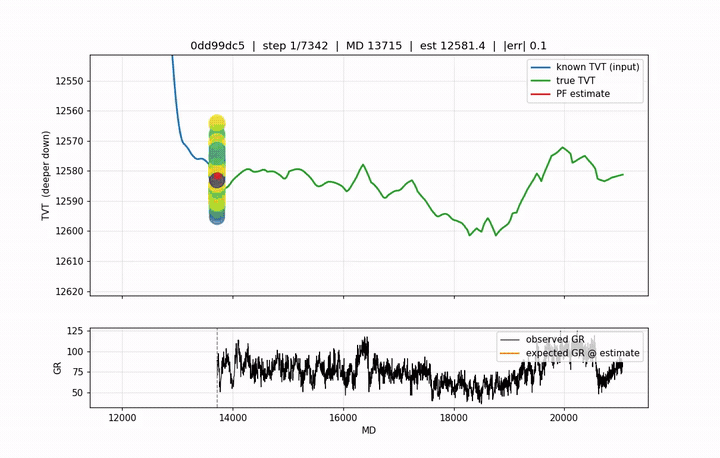

In [7]:
gif_path = make_gif(ani_follow, target_mb=4.8)
Image(gif_path)